# Intro and initial EDA

https://www.sciencedirect.com/science/article/pii/S0957417424017895#sec3

In [5]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))


In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix 
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "plotly_mimetype"

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from data import utils


# Load Data

In [7]:
non_spectral_df = pd.read_csv("../data/raw/non_spectral_df.csv", index_col=0)
non_spectral_df["Timestamp"] = pd.to_datetime(non_spectral_df["Timestamp"])

spectral_df = pd.read_csv("../data/raw/spectral_df.csv", index_col=0)
spectral_df["Timestamp"] = pd.to_datetime(spectral_df["Timestamp"])

grouped_spectral_df = pd.read_csv("../data/raw/grouped_spectral_df.csv", index_col=0)
grouped_spectral_df["Timestamp"] = pd.to_datetime(grouped_spectral_df["Timestamp"])

master_df = utils.merge_with_master(grouped_spectral_df, non_spectral_df)

In [8]:
eng_non_spectral_df  = pd.read_csv("../data/processed/eng_non_spectral_df.csv", index_col=0)
eng_non_spectral_df["Timestamp"] = pd.to_datetime(eng_non_spectral_df["Timestamp"])
eng_non_spectral_df["in_season"] = eng_non_spectral_df["in_season"].astype('category')
eng_non_spectral_df["Growth_Stage"] = eng_non_spectral_df["Growth_Stage"].astype('category')
master_eng = utils.merge_with_master(grouped_spectral_df, eng_non_spectral_df)

roll_lag_df = pd.read_csv("../data/processed/roll_lag_df.csv", index_col=0)
roll_lag_df["Timestamp"] = pd.to_datetime(roll_lag_df["Timestamp"])
master_roll_lag_df = utils.merge_with_master(grouped_spectral_df, roll_lag_df)

# Plots 

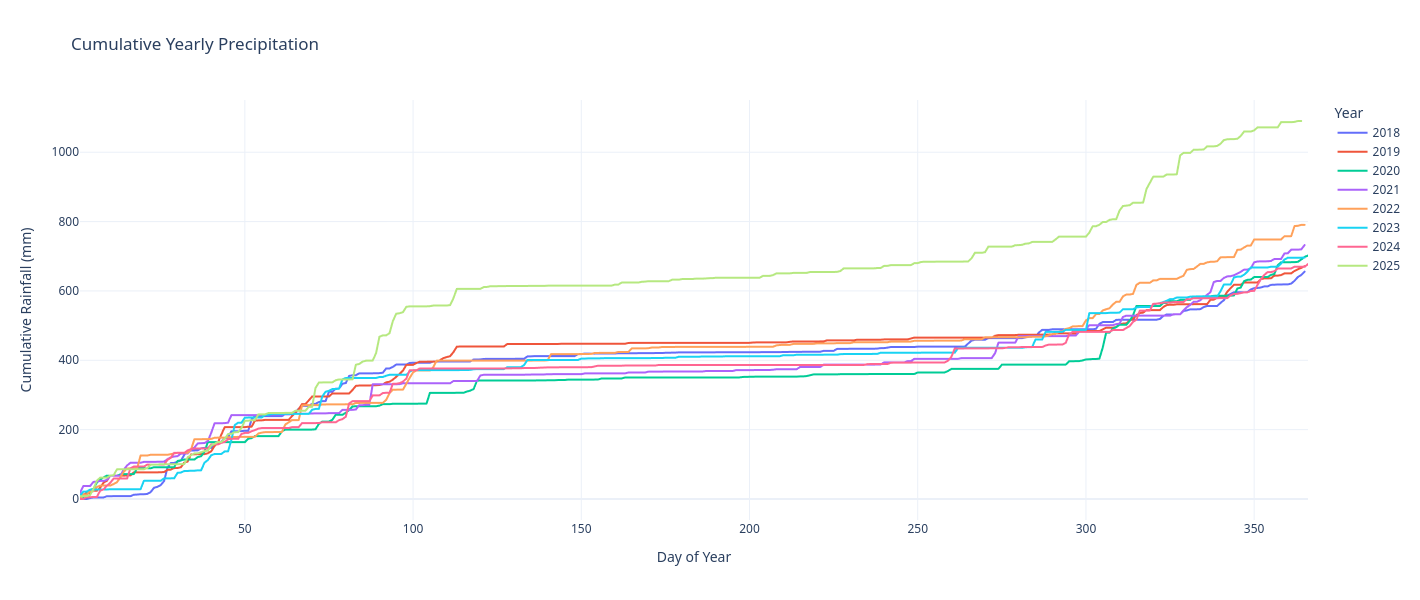

In [9]:
non_spectral_df["Year"] = non_spectral_df["Timestamp"].dt.year.astype(str) # Convert to string for discrete legend colors
non_spectral_df["doy"] = non_spectral_df["Timestamp"].dt.dayofyear

df_sorted = non_spectral_df.sort_values(["Year", "doy"])
df_sorted["cumulative_precipitation"] = df_sorted.groupby("Year")["precipitation"].cumsum()


fig = px.line(
    df_sorted, 
    x="doy", 
    y="cumulative_precipitation", 
    color="Year",
    title="Cumulative Yearly Precipitation",
    labels={"doy": "Day of Year", "cumulative_precipitation": "Cumulative Rainfall (mm)"},
    template="plotly_white",
    height=600
)

fig.update_layout(hovermode="x unified")

fig.show()

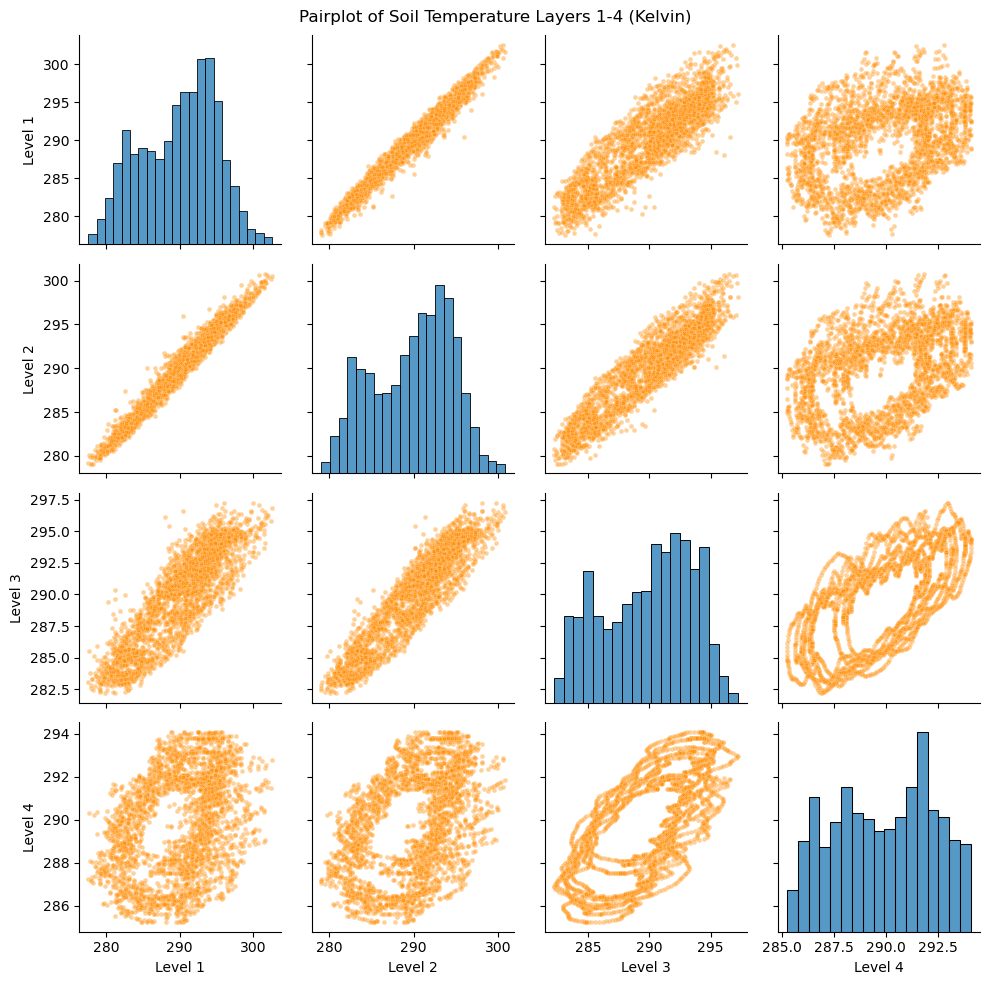

In [12]:
prefix = "soil_temperature_level"
layers = range(1, 5)
df_stl_plot = non_spectral_df[[f"{prefix}_{l}" for l in layers]]
df_stl_plot = df_stl_plot.rename(columns={ f"{prefix}_{l}" : f"Level {l}" for l in layers})

 
g = sns.pairplot(df_stl_plot, plot_kws={"color": "darkorange", "alpha": 0.4, "s":12})
g.fig.suptitle("Pairplot of Soil Temperature Layers 1-4 (Kelvin)")
g.fig.tight_layout()

plt.show()

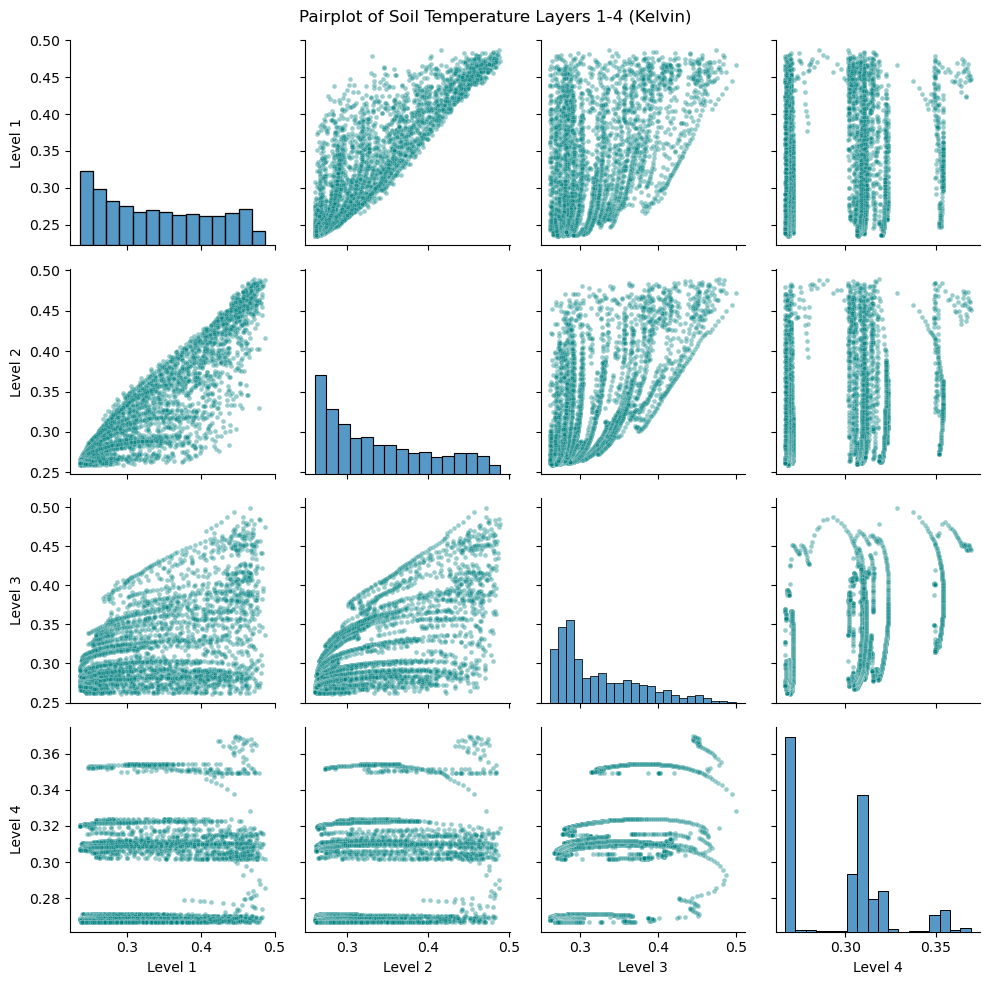

In [13]:
prefix = "volumetric_soil_water_layer"
layers = range(1, 5)
df_vwl_plot = non_spectral_df[[f"{prefix}_{l}" for l in layers]]
df_vwl_plot = df_vwl_plot.rename(columns={ f"{prefix}_{l}" : f"Level {l}" for l in layers})

 
g = sns.pairplot(df_vwl_plot, plot_kws={"color": "teal", "alpha": 0.4, "s":12})
g.fig.suptitle("Pairplot of Soil Temperature Layers 1-4 (Kelvin)")
g.fig.tight_layout()

plt.show()